# Kundensegmentierung mit Clustering (RFM + K-Means) 
## Ziel der Analyse
Ziel ist es, die Kunden anhand ihres Kaufverhaltens zu segmentieren. Hierzu werden Transaktionsdaten eines online Einzelhändlers analysiert und pro Kunde drei zentrale Merkmale berechnet:

- **Recency:** Tage seit dem letzten Kauf
- **Frequency:** Anzahl der Käufe
- **Monetary:** Gesamtumsatz des Kunden
 
Aus diesen RFM Merkmalen wird ein **Clustering-Verfahren (K-Means)** eingesetzt, um Kunden mit ähnlichem Kaufverhalten in Gruppen zu unterteilen.
rteilen.rteilen.

## Verwendete Libraries

Für die Analyse werden folgende Libraries benutzt:

- **pandas und numpy:** Datenverarbeitung und Allgemeine Datenaggregation
- **matplotlib:** Plotting / Visuelle Darstellungen
- **scikit-learn:** Clustering & Skalierung

Für die Ergebnisse wird ein fester `random_state` verwendet.
wendet.
wendet.
rwendet.


In [1]:
import pandas as pd 
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt
import sklearn
import matplotlib

## Versionsüberprüfung

Die verwendeten Bibliotheksversionen werden ausgegeben, um die Nachvollziehbarkeit zu steigern.
.



In [2]:
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)

pandas: 2.2.2
numpy: 1.26.4
scikit-learn: 1.4.2
matplotlib: 3.8.4


## Datensatz: Online Retail

Der hier verwendete Datensatz ist aus dem *UCI Machine Learning Repository* und enthält Transaktionsdaten eines Online-Einzelhändlers.

Jede einzelne Zeile steht für eine gekaufte Position auf einer Rechnung.

Wichtige Spalten sind
- `InvoiceNo`: Rechnngsnummer (beginnt mit “C” bei Stornierungen)
- `InvoiceDate`: Datum der Rechnung
- `Quantity`: Menge der gekauften Artikel
- `UnitPrice`: Preis pro Artikel
- `CustomerID`: Kunden-ID 

Der Datensatz enthält demnach sowohl Stornierungen als auch Einträge, die fehlerhaft sind, also Daten, die vor der Analyse bereinigt werden müssen.
rden müssen.
rden müssen.


In [3]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
df = pd.read_excel(url)

df.head(), df.shape

(  InvoiceNo StockCode                          Description  Quantity  \
 0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
 1    536365     71053                  WHITE METAL LANTERN         6   
 2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
 3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
 4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
 
           InvoiceDate  UnitPrice  CustomerID         Country  
 0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
 1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
 2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
 3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
 4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  ,
 (541909, 8))

## Erste Prüfung der Daten

Hierzu werden die Spaltennamen und Attributen auf Vollständigkeit geprüf

## Bereinigung der Daten

Nun werden einige Schritte durchgeführt, um sinnvolle RFM-Werte sicherzustellen.

1. Datensätze ohne `CustomerID` werden entfernt.
2. Stornierungen werden ausgeschlossen (durch InvoiceNo, das mit “C” beginnt)
3. Nur positive Mengen und Preise werden berücksichtigt.
4. Das `InvoiceDate` wird in ein Datumsformat umgewandelt.
5. Der Umsatz pro Position wird berechnet.

In [4]:
# Spaltennamen prüfen
print(df.columns)

# CustomerID muss vorhanden sein
df = df.dropna(subset=["CustomerID"]).copy()

#Stornos
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
df = df[~df["InvoiceNo"].str.startswith("C")].copy()

#sinnvolle Werte
df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)].copy()

#Datumsformat
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

#Umsatz pro Position
df["LineRevenue"] = df["Quantity"] * df["UnitPrice"]

df.shape, df.isna().sum().sort_values(ascending=False).head(10)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


((397884, 9),
 InvoiceNo      0
 StockCode      0
 Description    0
 Quantity       0
 InvoiceDate    0
 UnitPrice      0
 CustomerID     0
 Country        0
 LineRevenue    0
 dtype: int64)

## RFM-Feature Engineering

Aus den Transaktionsdaten, die nun bereinigt wurden, wird für jeden Kunden eine Art RFM-Profil erstellt.

Als Referenzdatum (hier im Code genannt: Snapshot Date) wird das maximale Rechnungsdatum mit ein Tag aufaddiert verwendet, damit die Recency am Ende immer positiv t.
 ist.


In [5]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("CustomerID")
    .agg(
        Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineRevenue", "sum"),
    )
    .reset_index()
)
rfm.head(), rfm.describe()


(   CustomerID  Recency  Frequency  Monetary
 0     12346.0      326          1  77183.60
 1     12347.0        2          7   4310.00
 2     12348.0       75          4   1797.24
 3     12349.0       19          1   1757.55
 4     12350.0      310          1    334.40,
          CustomerID      Recency    Frequency       Monetary
 count   4338.000000  4338.000000  4338.000000    4338.000000
 mean   15300.408022    92.536422     4.272015    2054.266460
 std     1721.808492   100.014169     7.697998    8989.230441
 min    12346.000000     1.000000     1.000000       3.750000
 25%    13813.250000    18.000000     1.000000     307.415000
 50%    15299.500000    51.000000     2.000000     674.485000
 75%    16778.750000   142.000000     5.000000    1661.740000
 max    18287.000000   374.000000   209.000000  280206.020000)

## Explorative Datenanalyse

Zur ersten Einschätzung der Kundenverteilung wird ein Scatterplot von Recency gegen Monetary erstellt.


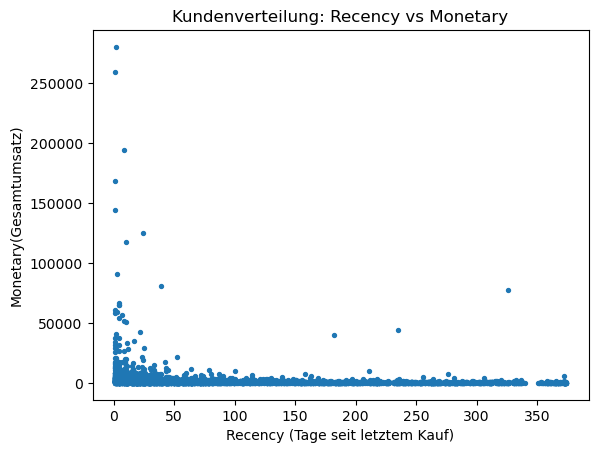

In [6]:
plt.figure()
plt.scatter(rfm["Recency"], rfm["Monetary"], s=8)
plt.xlabel("Recency (Tage seit letztem Kauf)")
plt.ylabel("Monetary(Gesamtumsatz)")
plt.title("Kundenverteilung: Recency vs Monetary")
plt.show()

## Skalierung von Merkmalen

Weil K-Means im Grunde genommen auf Distanzberechnungen aufbaut bzw. basiert, müssen die Merkmale hinsichtlich RFM vor dem Clustering unbedingt skaliert werde.


In [7]:
X = rfm[["Recency", "Frequency", "Monetary"]].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Die Bestimmung der optimalen Clusteranzahl

Die Anzahl der Clust ist bisher noch nicht eindeutig bekannt, weshalb wir diesen mithilfe des Silhouette Scores bestimme



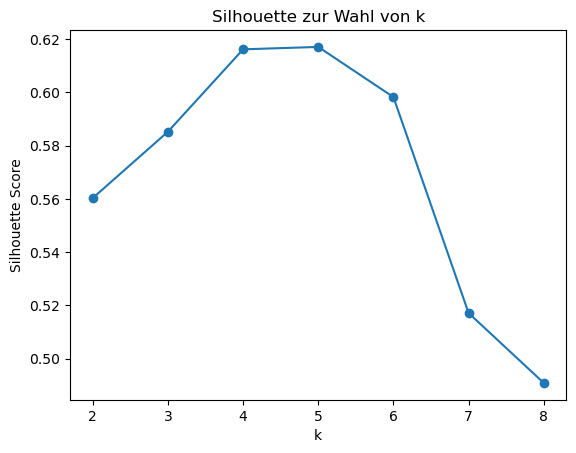

5

In [8]:
ks = range(2,9)
sil_scores = []
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure()
plt.plot(list(ks), sil_scores, marker = "o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.title("Silhouette zur Wahl von k")
plt.show()
best_k = ks[int(np.argmax(sil_scores))]
best_k

## Finales K-Means-Modell

Das K-Means-Modell wird trainiert mit der gewählten Clusteranzahl und dann wird die Clusterqualität bewertet.

In [9]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, rfm["Cluster"])
db = davies_bouldin_score(X_scaled, rfm["Cluster"])

sil, db

(0.617115186725246, 0.7135609370113026)

## Cluster-Profiling

Für eine Interpretation der Kundensegmente werden nun statistische Kennzahlen - und zwar pro Cluster - berechne.


In [10]:
profile = (
    rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]]
        .agg(["count", "median", "mean"])
)

profile


Recency                    Frequency                    Monetary  \
          count median        mean     count median        mean    count   
Cluster                                                                    
0          3060   32.5   43.808170      3060    3.0    3.686928     3060   
1          1063  243.0  248.469426      1063    1.0    1.553151     1063   
2             6    1.0    1.500000         6  110.5  135.833333        6   
3           203    5.0   15.724138       203   19.0   22.300493      203   
4             6    5.0    7.666667         6   50.5   42.833333        6   

                                    
             median           mean  
Cluster                             
0           827.355    1358.774086  
1           310.050     480.423604  
2         49908.700   58381.123333  
3          8109.520   13533.997044  
4        181511.645  190863.461667

## Interpretation der Clusterzentren

Die Clusterzentren werden zurück in die Originalskala transformiert, damit man typische Kundenprofile pro Segment erhalten kann.

In [11]:
centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids, columns=["Recency", "Frequency", "Monetary"])
centroids_df["Cluster"] = range(best_k)
centroids_df.sort_values("Monetary", ascending=False)

,Recency,Frequency,Monetary,Cluster
4,7.666667,42.833333,190863.461667,4
2,1.500000,135.833333,58381.123333,2
3,15.666667,22.264706,13480.774314,3
0,43.855229,3.683007,1358.860191,0
1,248.564030,1.551789,478.107581,1


## Analyse der Trennschärfe der RFM Merkmale

Um zu verstehen, welches der RFM Merkmale die Cluster am stärksten voneinander unterscheidet, wird die Varianz der Clusterzentren betrachtet.

Ein Merkmal mit hoher Varianz über die Clusterzentren trägt besonders stark zur Segmentierung bei und besitzt somit eine hohe Trennschäfe.
rfe.



In [12]:
cent = pd.DataFrame(centroids_scaled, columns=["Recency","Frequency","Monetary"])
feature_separation = cent.var().sort_values(ascending=False)
feature_separation

Monetary     80.527105
Frequency    51.886551
Recency       1.097042
dtype: float64

## Festlegung der finalen Clusteranzahl

Vorher wurde die Silhouette-Analyse durchgeführt. Darauf aufbauend wird nun die Anzahl der Cluster festgelegt - und zwar auf **k = 5**.

Diese Anzahl eignet sich sehr gut, denn:
- gute Trennschärfe der Cluster
- ausreichende Intrepretierbarkeit der Semente
mente


In [13]:
# K wird als 5 festgelegt.
kmeans_5 = KMeans(n_clusters=5, random_state = 42, n_init="auto")
rfm["Cluster"] = kmeans_5.fit_predict(X_scaled)

## Visualisierung der finalen Kundensegmente (Recency vs Monetary)

In dieser Darstellung stellen wir die endgültigen finalen Kundensegmente anhand der Merkmale **Recency** (Tage seit letztem Kauf) und **Monetary** (Gesamtumsatz) visuell dar.

Dabei entspricht jeder Punkt genau einem Kunden und die Farben markieren die zugewiesenen Cluster.

Durch diese Visualisierung bzw. Darstellung ist eine viel bessere Bewertung - bzgl. klarer Unterscheidung voneinander - möglich, und zwar hinsichtlich:
- kürzlich aktive und umsatzstarke Kunden
- inaktive Kunden
- umsatzschwache Kunden
e Kunden


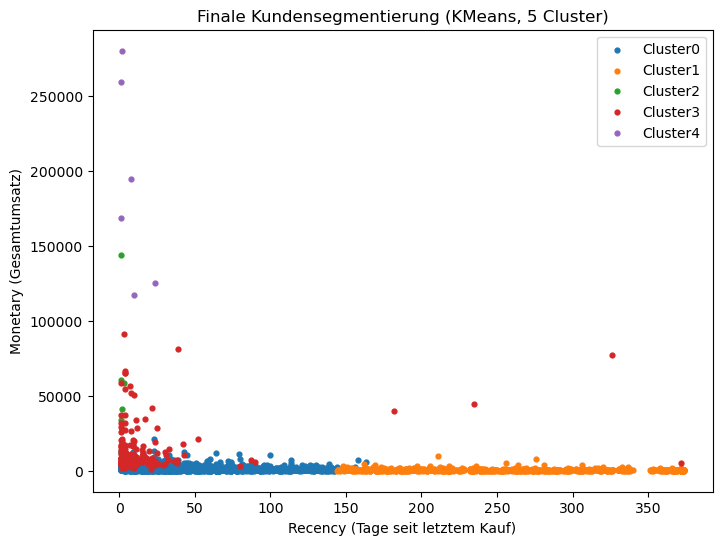

In [14]:
plt.figure(figsize=(8,6))

for c in sorted(rfm["Cluster"].unique()):
    cluster_data = rfm[rfm["Cluster"] == c]
    plt.scatter(
        cluster_data["Recency"],
        cluster_data["Monetary"],
        s=12,
        label=f"Cluster{c}"
        )

plt.xlabel("Recency (Tage seit letztem Kauf)")
plt.ylabel("Monetary (Gesamtumsatz)")
plt.title("Finale Kundensegmentierung (KMeans, 5 Cluster)")
plt.legend()
plt.show()

## Visuelle Darstellung der finalen Kundensegmente (Frequency vs Monetary)

Die Kundensegmente hinsichtlich **Kaufhäufigkeit (Frequency)** und **Gesamtumsatz (Monetary)** sind in dieser Visualisierung sichtbar.

Daher eignet sich dieses Scatterplot sehr gut für folgende Aspekte:
- Vielkäufer mit hohem Umsatz
- Gelegenheitskäufer
- umsatzschwache Gruppen von Kunden
atz
- Gelegenheitskäufer
- umsatzschwache Kundengruppen

visuell voneinander abzugrenzen.


<function matplotlib.pyplot.show(close=None, block=None)>

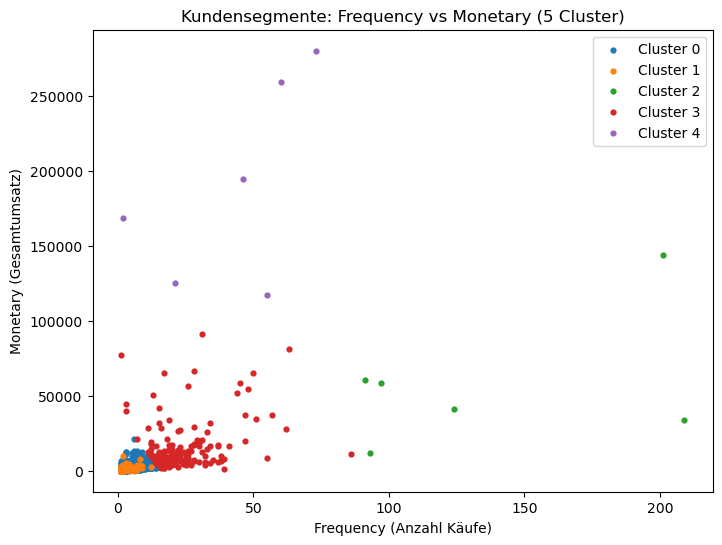

In [15]:
plt.figure(figsize=(8,6))

for c in sorted(rfm["Cluster"].unique()):
	cluster_data = rfm[rfm["Cluster"] == c]
	plt.scatter(
		cluster_data["Frequency"],
		cluster_data["Monetary"],
		s=12,
		label=f"Cluster {c}"
	)

plt.xlabel("Frequency (Anzahl Käufe)")
plt.ylabel("Monetary (Gesamtumsatz)")
plt.title("Kundensegmente: Frequency vs Monetary (5 Cluster)")
plt.legend()
plt.show

## Zusammenfassung

Für diese Kundengruppen kamen RFM und K-Means zum Einsatz.
Die beiden Methoden wurden verwendet, um die Kunden eines Online-Einzelhändlers zu segmentieren.

Die Resultate zeigen nun, dass man die Kunden anhand der Merkmale (RFM) in Gruppen einteilen kann - und das sehr klar unterscheidbar.

Nun können die resultierenden Kundensegmente als Basis verwendet werden, und zwar für folgendes:

- gezielte Marketingmaßnahmen
- Kundenbindungnsstrategien
- Priorisierung wertvoller Kunden
er Kunden
